In [3]:
from datasets import load_dataset
import pandas as pd

# Fix: use full path 'stanfordnlp/imdb'
dataset = load_dataset("stanfordnlp/imdb")

# Convert to dataframe
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nClass balance:\n{train_df['label'].value_counts()}")
print(f"\nSample review:\n{train_df['text'][0][:300]}")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size:  25000

Class balance:
label
0    12500
1    12500
Name: count, dtype: int64

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


In [4]:
import re

def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags like <br />
    text = re.sub(r'[^a-z0-9\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra whitespace
    return text

# Apply cleaning
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Compare before and after
print("BEFORE:")
print(train_df['text'][0][:300])
print("\nAFTER:")
print(train_df['clean_text'][0][:300])

BEFORE:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to s


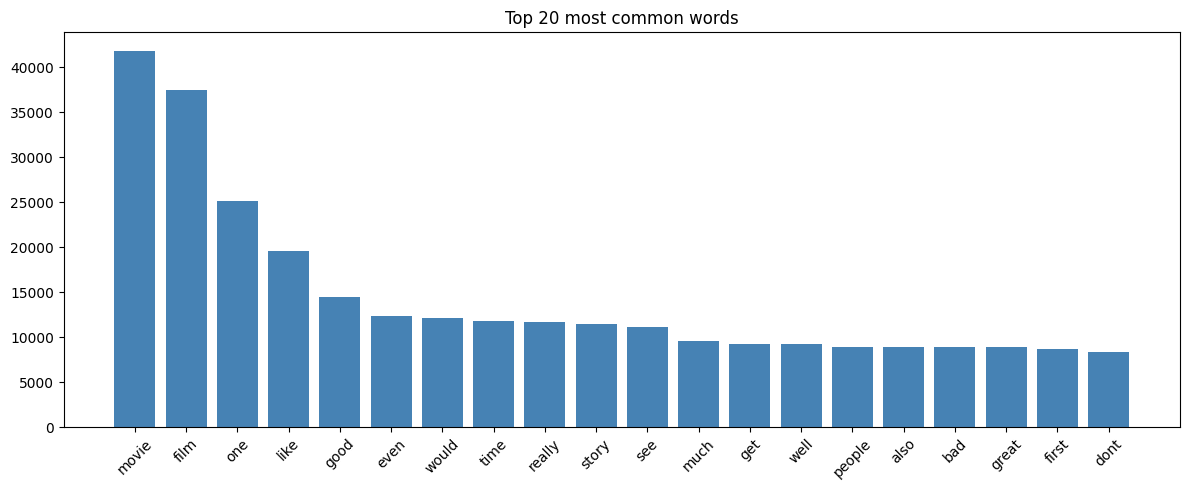

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

# Count all words across training set
all_words = ' '.join(train_df['clean_text']).split()
word_counts = Counter(all_words)
top_words = word_counts.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 most common words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text_v2(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# Apply updated cleaner
train_df['clean_text'] = train_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))
test_df['clean_text'] = test_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))

print("Sample after stopword removal:")
print(train_df['clean_text'][0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample after stopword removal:
rented curiousyellow video store controversy surrounded first released 1967 also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular
